# Day 2 - EOS, relaxation, and phonons with ASE and MLIPs

This notebook runs three ASE-based tasks for Si and AlAs using the UPET PET-MAD foundation model:

- EOS scans and Birch-Murnaghan fits
- Hydrostatic cell relaxations compared to the EOS minima
- Phonon band structures from finite displacements


In [1]:
import math
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read, write
from ase.build import bulk
from ase.filters import UnitCellFilter, FrechetCellFilter
from ase.optimize import BFGS
from ase.phonons import Phonons


In [2]:
ROOT = Path.cwd().resolve()

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("TORCH_COMPILE_DISABLE", "1")
os.environ.setdefault("TORCHINDUCTOR_DISABLE", "1")

plt.style.use("seaborn-v0_8-whitegrid")


## USER PARAMETERS

### Model

In [3]:
MODEL_KEY = "upet"
MODEL_LABELS = {
    "upet": "UPET PET-MAD",
}
MODEL_VERSION = {
    "upet": "pet-mad-s",
}


### Calculation parameters

In [ ]:
EOS_SCALE_MIN = 0.94
EOS_SCALE_MAX = 1.06
EOS_POINTS = 7
RELAX_FMAX = 0.005
RELAX_STEPS = 100
PHONON_SUPERCELL = (4,4,4) # Increase supercell size for better convergence of phonon frequencies. E.g. (5,5,5)
PHONON_DELTA = 0.005
PHONON_NPOINTS = 120
OUTPUT_DIR = ROOT / "notebook_outputs" / MODEL_KEY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

structures = {
    "Si": bulk("Si", "diamond", a=5.43, cubic=False),
    "AlAs": bulk("AlAs", "zincblende", a=5.556, cubic=False)
}


## Helper functions

In [32]:
def get_formula_units(atoms):
    counts = Counter(atoms.get_chemical_symbols())
    values = list(counts.values())
    result = values[0]
    for value in values[1:]:
        result = math.gcd(result, value)
    return result

def bm3_E(V, E0, V0, B0, B1):
    eta = (V0 / V) ** (2.0 / 3.0)
    t = eta - 1.0
    return E0 + (9.0 * V0 * B0 / 16.0) * (t ** 3 * B1 + t ** 2 * (6.0 - 4.0 * eta))

def fit_bm3(V, E):
    from scipy.optimize import curve_fit

    V = np.asarray(V, dtype=float)
    E = np.asarray(E, dtype=float)
    p0 = [float(np.min(E)), float(V[np.argmin(E)]), 0.5, 4.0]
    popt, _ = curve_fit(bm3_E, V, E, p0=p0, maxfev=20000)
    return tuple(map(float, popt))

def build_calculator(model_key):
    if model_key == "upet":
        from upet.calculator import UPETCalculator
        return UPETCalculator(model=MODEL_VERSION[model_key], version="1.5.0", device="cpu")

    raise ValueError(f"Unknown model key: {model_key}")

calc = build_calculator(MODEL_KEY)
print(f"Using model: {MODEL_LABELS[MODEL_KEY]} ({MODEL_VERSION[MODEL_KEY]})")


Using model: UPET PET-MAD (pet-mad-s)


## 0. Visualize the crystal structures

Before any calculation, let's take a look at the two test systems. Si (diamond cubic) and AlAs (zinc-blende) are classic benchmarks covering a covalent semiconductor and a polar semiconductor — a good spread of bonding characters for testing a foundation model.


In [33]:
import chemiscope, ipywidgets as widgets, math; from collections import Counter
SUPERCELL = (3,3,3)
atoms=list(structures.values())
names=list(structures.keys())
vfu=[a.get_volume()/math.gcd(*Counter(a.get_chemical_symbols()).values()) for a in atoms]
widgets.HBox([(lambda w: (setattr(w, "layout", widgets.Layout(width="260px", height="450px")) or w))(chemiscope.show(structures=atoms, mode="map", properties={"index": {"target": "structure", "values": list(range(len(atoms)))}, "volume_per_fu": {"target": "structure", "values": vfu}, "name": {"target": "structure", "values": names}}, settings={"map": {"x": {"property": "index"}, "y": {"property": "volume_per_fu"}, "symbol": "name"}})), widgets.GridBox([(lambda w: (setattr(w, "layout", widgets.Layout(width="450px", height="450px")) or w))(chemiscope.show(structures=[a], mode="structure", settings={"structure": [{"unitCell": True, "supercell": {"0": SUPERCELL[0], "1": SUPERCELL[1], "2": SUPERCELL[2]}, "bonds": True, "spaceFilling": False, "keepOrientation": True}]})) for a in atoms], layout=widgets.Layout(grid_template_columns="repeat(3, 450px)", grid_template_rows="450px", grid_gap="8px"))], layout=widgets.Layout(width="100%", align_items="flex-start", gap="12px"))

## 1. Equation of state

We scale the unit cell isotropically over a range of volumes and evaluate the total energy at each point. Fitting a 3rd-order Birch–Murnaghan (BM3) EOS to the resulting $E(V)$ curve yields the equilibrium volume $V_0$, the cohesive energy $E_0$, the bulk modulus $B_0$, and its pressure derivative $B_1'$. This is a cheap and model-independent way to probe the energy landscape around the ground state.


/home/fioren_a/miniforge3/envs/metatrain/lib/python3.10/site-packages/metatomic/torch/ase_calculator.py:1482: UserWarning: `compute_requested_neighbors_from_options` is deprecated and will be removed in a future version. Please use `neighbor_lists_for_model` to get the calculators and call them directly.
  vesin.metatomic.compute_requested_neighbors_from_options(


[1] Si: V0 = 20.1926 A^3/f.u., E0 = -5.890828 eV/f.u., B0 = 92.95 GPa, B1 = 4.088
[1] AlAs: V0 = 45.7796 A^3/f.u., E0 = -10.447354 eV/f.u., B0 = 72.55 GPa, B1 = 4.365
Saved /home/fioren_a/useful_repos/ictp-marvel-college-2026/day-02-lattice-dynamics/03_phonons_mlip/notebook_outputs/upet/upet_eos.png


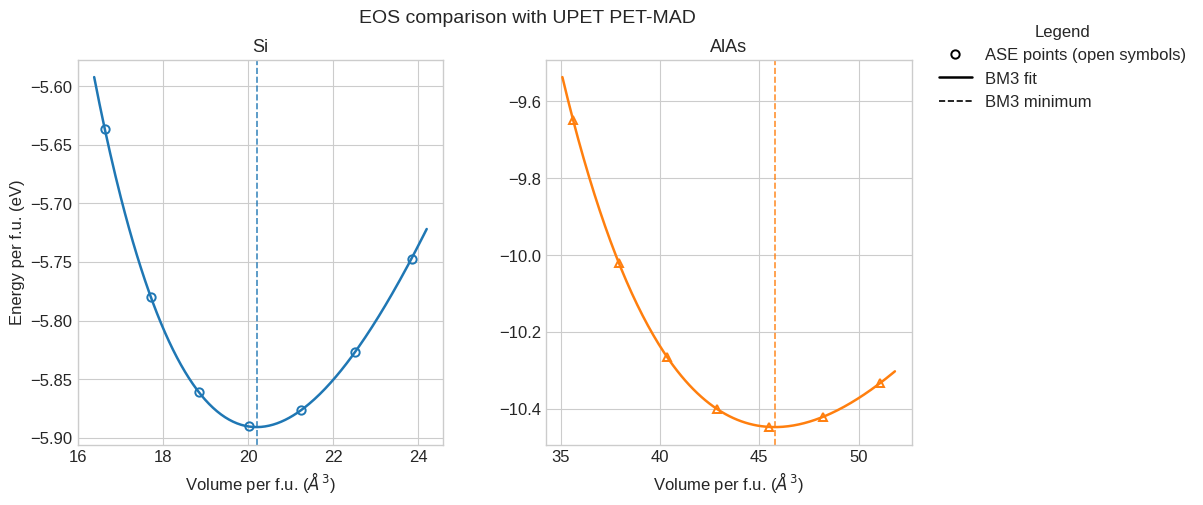

In [34]:
from matplotlib.lines import Line2D

eos_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
fig.subplots_adjust(right=0.82, wspace=0.28)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = {"Si": "o", "AlAs": "^"}

for idx, (ax, (name, atoms0)) in enumerate(zip(axes, structures.items())):
    scale_values = np.linspace(EOS_SCALE_MIN, EOS_SCALE_MAX, EOS_POINTS)
    volumes_total = []
    energies_total = []

    for i, scale in enumerate(scale_values):
        print(f"{i+1}/{len(scale_values)} scale {scale:.4f}...", end="\r")
        atoms = atoms0.copy()
        atoms.set_cell(atoms.cell * scale, scale_atoms=True)
        atoms.calc = calc
        volumes_total.append(float(atoms.get_volume()))
        energies_total.append(float(atoms.get_potential_energy()))

    n_atoms = len(atoms0)
    n_fu = get_formula_units(atoms0)
    volumes = np.array(volumes_total) / n_fu
    energies = np.array(energies_total) / n_fu
    E0, V0, B0, B1 = fit_bm3(volumes, energies)

    volume_fit = np.linspace(volumes.min() * 0.985, volumes.max() * 1.015, 250)
    energy_fit = bm3_E(volume_fit, E0, V0, B0, B1)
    color = colors[idx % len(colors)]

    eos_results[name] = {
        "structure": atoms0.copy(),
        "n_atoms": n_atoms,
        "n_fu": n_fu,
        "scale_values": scale_values,
        "volume_total_A3": np.array(volumes_total),
        "energy_total_eV": np.array(energies_total),
        "volume_per_fu_A3": volumes,
        "energy_per_fu_eV": energies,
        "fit": {
            "E0_eV_per_fu": E0,
            "V0_A3_per_fu": V0,
            "B0_eV_per_A3": B0,
            "B1_dimensionless": B1,
            "B0_GPa": B0 * 160.21766208,
        },
    }

    ax.plot(
        volumes,
        energies,
        marker=markers[name],
        linestyle="none",
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
    )
    ax.plot(volume_fit, energy_fit, color=color, linewidth=1.8)
    ax.axvline(V0, color=color, linestyle="--", linewidth=1.2, alpha=0.85)

    ax.set_title(name, fontsize=13)
    ax.set_xlabel(r"Volume per f.u. ($\AA^3$)", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)

    print(f"[1] {name}: V0 = {V0:.4f} A^3/f.u., E0 = {E0:.6f} eV/f.u., B0 = {B0 * 160.21766208:.2f} GPa, B1 = {B1:.3f}")

axes[0].set_ylabel(r"Energy per f.u. (eV)", fontsize=12)

eos_handles = [
    Line2D([0], [0], marker="o", linestyle="none", color="k", markerfacecolor="none", markeredgecolor="k", markeredgewidth=1.4, markersize=6, label="ASE points (open symbols)"),
    Line2D([0], [0], linestyle="-", color="k", linewidth=1.8, label="BM3 fit"),
    Line2D([0], [0], linestyle="--", color="k", linewidth=1.2, label="BM3 minimum"),
]
fig.legend(handles=eos_handles, loc="upper left", bbox_to_anchor=(0.83, 0.98), fontsize=12, title="Legend", title_fontsize=12)
fig.suptitle(f"EOS comparison with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

eos_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_eos.png"
fig.savefig(eos_plot_path, dpi=220)
print(f"Saved {eos_plot_path}")


## 2. Structural relaxation

Now we let the cell relax freely using ASE's `FrechetCellFilter` with hydrostatic strain, which allows the volume to change while preserving the crystal symmetry. The optimizer converges when the maximum force component drops below `RELAX_FMAX`. Comparing the relaxed volume $V_\text{relax}$ and energy $E_\text{relax}$ to the BM3 minimum $V_0$/$E_0$ is a sanity check: they should agree closely if the EOS scan was dense enough and the model is well-behaved.


### 2.a. Relax

In [35]:
relax_results = {}
relaxed_atoms = {}

for name, atoms0 in structures.items():
    atoms = atoms0.copy()
    atoms.calc = calc
    ucf = FrechetCellFilter(atoms, hydrostatic_strain=True)
    opt = BFGS(ucf, logfile=None)
    opt.run(fmax=RELAX_FMAX, steps=RELAX_STEPS)
    atoms = ucf.atoms

    relaxed_atoms[name] = atoms.copy()

    n_fu = get_formula_units(atoms0)
    e_relax = float(atoms.get_potential_energy()) / n_fu
    v_relax = float(atoms.get_volume()) / n_fu

    e0 = eos_results[name]["fit"]["E0_eV_per_fu"]
    v0 = eos_results[name]["fit"]["V0_A3_per_fu"]

    relax_results[name] = {
        "E_relax_eV_per_fu": e_relax,
        "V_relax_A3_per_fu": v_relax,
        "E0_EOS_eV_per_fu": e0,
        "V0_EOS_A3_per_fu": v0,
        "dE_meV_per_fu": 1000.0 * (e_relax - e0),
        "dV_percent": 100.0 * (v_relax - v0) / v0,
        "n_atoms": len(atoms),
        "n_fu": n_fu,
        "final_cell": atoms.cell.array.copy(),
        "final_positions": atoms.positions.copy(),
    }

    print(
        f"[2] {name}: V_relax = {v_relax:.4f} A^3/f.u. vs V0 = {v0:.4f} A^3/f.u. | "
        f"dV = {relax_results[name]['dV_percent']:+.2f}% | "
        f"E_relax = {e_relax:.6f} eV/f.u. vs E0 = {e0:.6f} eV/f.u. | "
        f"dE = {relax_results[name]['dE_meV_per_fu']:+.2f} meV/f.u."
    )


[2] Si: V_relax = 20.1969 A^3/f.u. vs V0 = 20.1926 A^3/f.u. | dV = +0.02% | E_relax = -5.890818 eV/f.u. vs E0 = -5.890828 eV/f.u. | dE = +0.01 meV/f.u.
[2] AlAs: V_relax = 45.7783 A^3/f.u. vs V0 = 45.7796 A^3/f.u. | dV = -0.00% | E_relax = -10.447277 eV/f.u. vs E0 = -10.447354 eV/f.u. | dE = +0.08 meV/f.u.


### 2.b. Plot relaxed volume on top of EOS results

Saved /home/fioren_a/useful_repos/ictp-marvel-college-2026/day-02-lattice-dynamics/03_phonons_mlip/notebook_outputs/upet/upet_relaxation_comparison.png


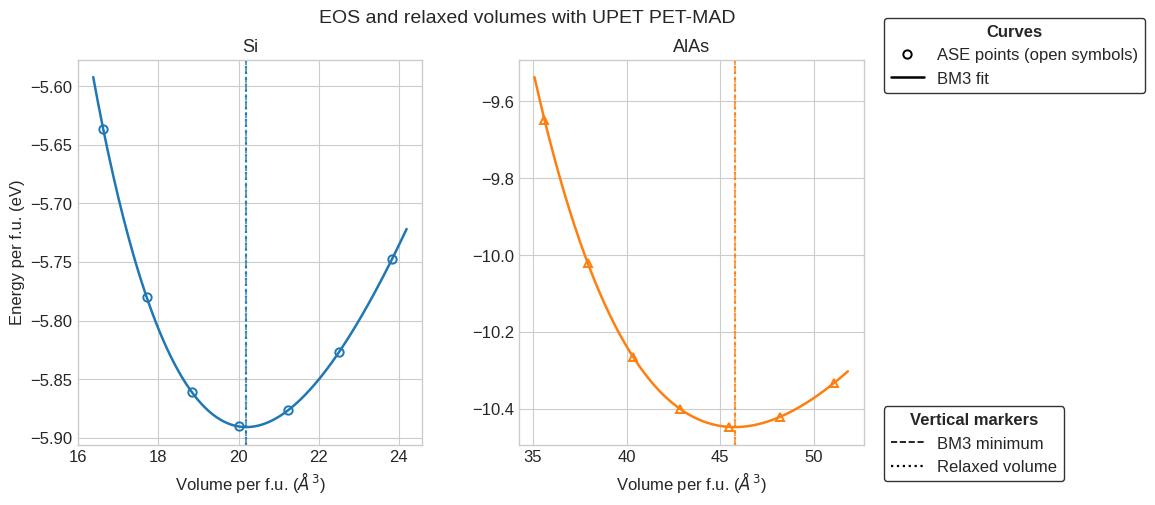

In [36]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
fig.subplots_adjust(right=0.78, wspace=0.28)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = {"Si": "o", "AlAs": "^"}

for idx, (ax, name) in enumerate(zip(axes, structures.keys())):
    data = eos_results[name]
    fit = data["fit"]
    volume_fit = np.linspace(data["volume_per_fu_A3"].min() * 0.985, data["volume_per_fu_A3"].max() * 1.015, 250)
    energy_fit = bm3_E(volume_fit, fit["E0_eV_per_fu"], fit["V0_A3_per_fu"], fit["B0_eV_per_A3"], fit["B1_dimensionless"])
    color = colors[idx % len(colors)]

    ax.plot(
        data["volume_per_fu_A3"],
        data["energy_per_fu_eV"],
        marker=markers[name],
        linestyle="none",
        color=color,
        markerfacecolor="none",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
    )
    ax.plot(volume_fit, energy_fit, color=color, linewidth=1.8)
    ax.axvline(fit["V0_A3_per_fu"], color=color, linestyle="--", linewidth=1.2, alpha=0.85)
    ax.axvline(relax_results[name]["V_relax_A3_per_fu"], color=color, linestyle=":", linewidth=1.6, alpha=0.9)

    ax.set_title(name, fontsize=13)
    ax.set_xlabel(r"Volume per f.u. ($\AA^3$)", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)

axes[0].set_ylabel(r"Energy per f.u. (eV)", fontsize=12)
fig.suptitle(f"EOS and relaxed volumes with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

series_handles = [
    Line2D([0], [0], marker="o", linestyle="none", color="k", markerfacecolor="none", markeredgecolor="k", markeredgewidth=1.4, markersize=6, label="ASE points (open symbols)"),
    Line2D([0], [0], linestyle="-", color="k", linewidth=1.8, label="BM3 fit"),
]
vertical_handles = [
    Line2D([0], [0], linestyle="--", color="k", linewidth=1.2, label="BM3 minimum"),
    Line2D([0], [0], linestyle=":", color="k", linewidth=1.6, label="Relaxed volume"),
]

leg1 = fig.legend(handles=series_handles, fontsize=12, loc="upper left", bbox_to_anchor=(0.79, 0.98), title="Curves", title_fontsize=12, frameon=True, edgecolor="black")
leg1.get_title().set_fontweight("bold")
leg2 = fig.legend(handles=vertical_handles, fontsize=12, loc="lower left", bbox_to_anchor=(0.79, 0.02), title="Vertical markers", title_fontsize=12, frameon=True, edgecolor="black")
leg2.get_title().set_fontweight("bold")

relax_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_relaxation_comparison.png"
fig.savefig(relax_plot_path, dpi=220)
print(f"Saved {relax_plot_path}")


## 3. Phonon band structures

Phonons are the normal modes of atomic vibrations in a crystal. We compute them via the finite-displacement method: each atom in a supercell is slightly displaced ($\delta =$ `PHONON_DELTA` Å) and the resulting forces are used to build the force-constant matrix. Diagonalising it along a high-symmetry **k**-path gives the phonon dispersion. Imaginary frequencies (plotted as negative) indicate a dynamical instability. We start from the relaxed structures so that the forces at the undisplaced geometry are zero.


[3] Si: starting phonons (1500 displacements expected)
  [Si] displacement 1/1500


/home/fioren_a/miniforge3/envs/metatrain/lib/python3.10/site-packages/metatomic/torch/ase_calculator.py:1482: UserWarning: `compute_requested_neighbors_from_options` is deprecated and will be removed in a future version. Please use `neighbor_lists_for_model` to get the calculators and call them directly.
  vesin.metatomic.compute_requested_neighbors_from_options(


  [Si] displacement 2/1500
  [Si] displacement 3/1500
  [Si] displacement 4/1500
  [Si] displacement 5/1500
  [Si] displacement 6/1500
  [Si] displacement 7/1500
  [Si] displacement 8/1500
  [Si] displacement 9/1500
  [Si] displacement 10/1500
  [Si] displacement 11/1500
  [Si] displacement 12/1500
  [Si] displacement 13/1500
WARNING, 3 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.527e-05*i)
WARNING, 3 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 3.527e-05*i)
[3] Si: done — supercell=(5, 5, 5), delta=0.005 Å, npoints=120, freq range=[-0.0, 518.9] cm⁻¹
[3] AlAs: starting phonons (1500 displacements expected)
  [AlAs] displacement 1/1500


/home/fioren_a/miniforge3/envs/metatrain/lib/python3.10/site-packages/metatomic/torch/ase_calculator.py:1482: UserWarning: `compute_requested_neighbors_from_options` is deprecated and will be removed in a future version. Please use `neighbor_lists_for_model` to get the calculators and call them directly.
  vesin.metatomic.compute_requested_neighbors_from_options(


  [AlAs] displacement 2/1500
  [AlAs] displacement 3/1500
  [AlAs] displacement 4/1500
  [AlAs] displacement 5/1500
  [AlAs] displacement 6/1500
  [AlAs] displacement 7/1500
  [AlAs] displacement 8/1500
  [AlAs] displacement 9/1500
  [AlAs] displacement 10/1500
  [AlAs] displacement 11/1500
  [AlAs] displacement 12/1500
  [AlAs] displacement 13/1500
WARNING, 3 imaginary frequencies at q = ( 0.00,  0.00,  0.00) ; (omega_q = 9.150e-06*i)
WARNING, 1 imaginary frequencies at q = ( 0.02,  0.00,  0.02) ; (omega_q = 1.072e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.03,  0.00,  0.03) ; (omega_q = 1.910e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.05,  0.00,  0.05) ; (omega_q = 2.247e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.07,  0.00,  0.07) ; (omega_q = 1.509e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.06,  0.00,  0.06) ; (omega_q = 1.724e-02*i)
WARNING, 1 imaginary frequencies at q = ( 0.05,  0.00,  0.05) ; (omega_q = 2.247e-02*i)
WARNING, 1 imaginary frequencies

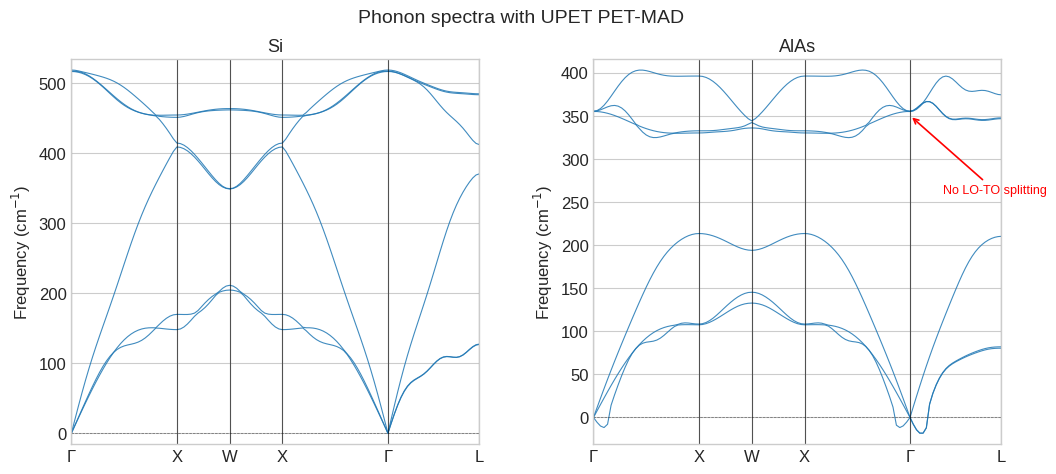

In [ ]:
phonon_results = {}

import shutil
shutil.rmtree("phonon", ignore_errors=True)

EV_TO_CM1 = 8065.544  # 1 eV = 8065.544 cm⁻¹

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0))
fig.subplots_adjust(wspace=0.28)

for ax, name in zip(axes, structures.keys()):
    atoms = relaxed_atoms[name].copy()

    # Wrap calculator to print progress on each displacement SCF
    n_expected = 6 * len(atoms) * PHONON_SUPERCELL[0] * PHONON_SUPERCELL[1] * PHONON_SUPERCELL[2]
    counter = [0]
    base_calc = calc

    class _VerboseCalc:
        def __init__(self, wrapped):
            self._w = wrapped
        def get_forces(self, a):
            counter[0] += 1
            print(f"  [{name}] displacement {counter[0]}/{n_expected}", flush=True)
            return self._w.get_forces(a)
        def __getattr__(self, item):
            return getattr(self._w, item)

    verbose_calc = _VerboseCalc(base_calc)
    atoms.calc = verbose_calc
    print(f"[3] {name}: starting phonons ({n_expected} displacements expected)")

    ph = Phonons(atoms, verbose_calc, supercell=PHONON_SUPERCELL, delta=PHONON_DELTA)
    ph.run()
    ph.read(acoustic=True)
    path = atoms.cell.bandpath("GXWXGL", npoints=PHONON_NPOINTS)
    band_structure = ph.get_band_structure(path)

    phonon_results[name] = {
        "path": path,
        "band_structure": band_structure,
    }

    # Plot in cm⁻¹ units
    x_coords, X_ticks, tick_labels = band_structure.get_labels()
    energies_cm1 = np.asarray(band_structure.energies)[0, :, :] * EV_TO_CM1  # (nkpoints, nbands)

    for mode in range(energies_cm1.shape[1]):
        ax.plot(x_coords, energies_cm1[:, mode], color="C0", lw=0.8, alpha=0.85)

    for xi in X_ticks:
        ax.axvline(xi, color="k", lw=0.8, alpha=0.6)
    ax.axhline(0, color="k", lw=0.5, linestyle="--", alpha=0.5)

    ax.set_xticks(X_ticks)
    ax.set_xticklabels([lbl.replace("G", "Γ") for lbl in tick_labels])
    ax.set_xlim(x_coords[0], x_coords[-1])

    e_flat = energies_cm1.ravel()
    margin = (e_flat.max() - e_flat.min()) * 0.03
    ax.set_ylim(e_flat.min() - margin, e_flat.max() + margin)

    ax.set_title(name, fontsize=13)
    ax.set_ylabel(r"Frequency (cm$^{-1}$)", fontsize=12)
    ax.tick_params(axis="both", labelsize=12)

    # Annotate the degenerate optical mode at both Γ points in AlAs.
    # Text sits midway between the two Γ points; two arrows point down to each.
    # (No LO-TO split because finite-displacement MLIPs lack long-range electrostatics.)
    if name == "AlAs":
        gamma1_x = X_ticks[0]   # first Γ  (path start)
        gamma2_x = X_ticks[4]   # second Γ (middle of GXWXGL)
        text_x = (gamma1_x + gamma2_x) / 2
        text_y = 350 + (e_flat.max() - 350) * 0.55  # halfway between optical branch and top

        ax.text(text_x, text_y, "No LO-TO splitting",
                ha="center", va="bottom", fontsize=9, color="red",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

        ax.annotate("", xy=(gamma1_x, 350), xytext=(text_x, text_y),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.2))
        ax.annotate("", xy=(gamma2_x, 350), xytext=(text_x, text_y),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.2))

    print(
        f"[3] {name}: done — supercell={PHONON_SUPERCELL}, "
        f"delta={PHONON_DELTA:.3f} Å, npoints={PHONON_NPOINTS}, "
        f"freq range=[{np.nanmin(e_flat):.1f}, {np.nanmax(e_flat):.1f}] cm⁻¹"
    )

    ph.clean()

fig.suptitle(f"Phonon spectra with {MODEL_LABELS[MODEL_KEY]}", fontsize=14)

phonon_plot_path = OUTPUT_DIR / f"{MODEL_KEY}_phonons.png"
fig.savefig(phonon_plot_path, dpi=220)
print(f"Saved {phonon_plot_path}")


## Summary

All results are collected in the dictionaries `eos_results`, `relax_results`, `relaxed_atoms`, and `phonon_results` for further analysis. The table below gives a concise numerical overview: EOS-fitted $V_0$, $B_0$, and $B_1'$; the deviation of the relaxed volume from the EOS minimum; and the phonon calculation settings used.


In [16]:
import pandas as pd
from IPython.display import display

rows_eos = []
rows_relax = []
rows_phonon = []

for name in structures.keys():
    eos = eos_results[name]["fit"]
    rel = relax_results[name]
    rows_eos.append(
        {
            "Structure": name,
            r"V0 EOS ($\AA^3$/f.u.)": eos["V0_A3_per_fu"],
            r"E0 EOS (eV/f.u.)": eos["E0_eV_per_fu"],
            r"B0 (GPa)": eos["B0_GPa"],
            r"B1": eos["B1_dimensionless"],
        }
    )
    rows_relax.append(
        {
            "Structure": name,
            r"V relax ($\AA^3$/f.u.)": rel["V_relax_A3_per_fu"],
            r"E relax (eV/f.u.)": rel["E_relax_eV_per_fu"],
            r"V0 EOS ($\AA^3$/f.u.)": rel["V0_EOS_A3_per_fu"],
            r"dV (%)": rel["dV_percent"],
            r"dE (meV/f.u.)": rel["dE_meV_per_fu"],
        }
    )
    rows_phonon.append(
        {
            "Structure": name,
            "Supercell": "x".join(map(str, PHONON_SUPERCELL)),
            r"Delta ($\AA$)": PHONON_DELTA,
            "npoints": PHONON_NPOINTS,
            "Path": "default bandpath",
        }
    )

eos_table = pd.DataFrame(rows_eos).set_index("Structure")
relax_table = pd.DataFrame(rows_relax).set_index("Structure")
phonon_table = pd.DataFrame(rows_phonon).set_index("Structure")

display(eos_table.style.format({
    r"V0 EOS ($\AA^3$/f.u.)": "{:.4f}",
    r"E0 EOS (eV/f.u.)": "{:.6f}",
    r"B0 (GPa)": "{:.2f}",
    r"B1": "{:.3f}",
}))

display(relax_table.style.format({
    r"V relax ($\AA^3$/f.u.)": "{:.4f}",
    r"E relax (eV/f.u.)": "{:.6f}",
    r"V0 EOS ($\AA^3$/f.u.)": "{:.4f}",
    r"dV (%)": "{:+.2f}",
    r"dE (meV/f.u.)": "{:+.2f}",
}))

display(phonon_table)

print(f"Outputs saved under: {OUTPUT_DIR}")


,V0 EOS ($\AA^3$/f.u.),E0 EOS (eV/f.u.),B0 (GPa),B1
Structure,,,,
Si,20.1926,-5.890828,92.95,4.088
AlAs,45.7796,-10.447354,72.55,4.365


,V relax ($\AA^3$/f.u.),E relax (eV/f.u.),V0 EOS ($\AA^3$/f.u.),dV (%),dE (meV/f.u.)
Structure,,,,,
Si,20.1969,-5.890818,20.1926,+0.02,+0.01
AlAs,45.7857,-10.447276,45.7796,+0.01,+0.08


,Supercell,Delta ($\AA$),npoints,Path
Structure,,,,
Si,4x4x4,0.01,120,default bandpath
AlAs,4x4x4,0.01,120,default bandpath


Outputs saved under: /home/fioren_a/useful_repos/ictp-marvel-college-2026/day-02-lattice-dynamics/03_phonons_mlip/notebook_outputs/upet
